In [1]:
!pip install opendatasets

In [2]:
import numpy as np
import pandas as pd
import opendatasets as od

od.download("https://www.kaggle.com/competitions/titanic/code")

100%|██████████| 34.1k/34.1k [00:00<00:00, 44.5MB/s]


Extracting archive ./titanic/titanic.zip to ./titanic


In [3]:
df = pd.read_csv("/content/titanic/train.csv")

In [4]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [5]:
print(df.info)

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [7]:
print(df.shape)

(891, 12)


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
data = df[["Pclass", "Sex", "Age"]].copy()

data["Age"] = data["Age"].fillna(data['Age'].mean())
data['Sex'] = data['Sex'].map({'male': 1, 'female': 0})

X = data[['Pclass', 'Sex', 'Age']].values
y = df['Survived'].values

In [15]:
np.random.seed(42)
idx = np.random.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [28]:
w = np.zeros(3)   # w1 Pclass, w2  Sex, w3 Age
b = 0
lr = 0.1
epochs = 1000

z = X @ w + b

In [29]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [30]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [31]:
p = sigmoid(z)

In [32]:
for epoch in range(epochs):
    z = X_train @ w + b
    p = sigmoid(z)

    loss = -np.mean(y_train * np.log(p) + (1 - y_train) * np.log(1 - p))

    dz = p - y_train
    dw = (X_train.T @ dz) / len(y_train)
    db = np.mean(dz)

    w = w - lr * dw
    b = b - lr * db

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.4666
Epoch 200, Loss: 0.4577
Epoch 300, Loss: 0.4565
Epoch 400, Loss: 0.4562
Epoch 500, Loss: 0.4562
Epoch 600, Loss: 0.4562
Epoch 700, Loss: 0.4562
Epoch 800, Loss: 0.4562
Epoch 900, Loss: 0.4562


In [33]:
z_test = X_test @ w + b
p_test = sigmoid(z_test)

pred = (p_test >= 0.5).astype(int)

accuracy = np.mean(pred == y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7877


AUC: 0.8621


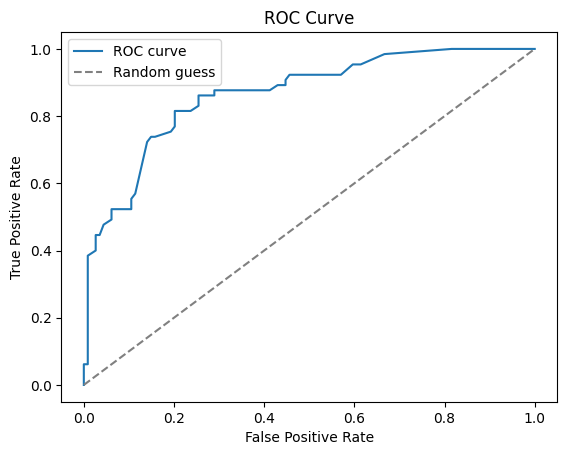

Best threshold: 0.45
Accuracy at best threshold: 0.8045


In [34]:
thresholds = np.arange(0, 1.01, 0.01)

tpr_list = []
fpr_list = []

for t in thresholds:
    pred_t = (p_test >= t).astype(int)

    TP = np.sum((pred_t == 1) & (y_test == 1))
    FP = np.sum((pred_t == 1) & (y_test == 0))
    TN = np.sum((pred_t == 0) & (y_test == 0))
    FN = np.sum((pred_t == 0) & (y_test == 1))

    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0

    tpr_list.append(tpr)
    fpr_list.append(fpr)

tpr_arr = np.array(tpr_list)
fpr_arr = np.array(fpr_list)

# sort by fpr for a proper AUC calc
sort_idx = np.argsort(fpr_arr)
fpr_sorted = fpr_arr[sort_idx]
tpr_sorted = tpr_arr[sort_idx]

auc = np.trapezoid(tpr_sorted, fpr_sorted)
print(f"AUC: {auc:.4f}")

# plot
import matplotlib.pyplot as plt
plt.plot(fpr_arr, tpr_arr, label="ROC curve")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# best threshold = biggest TPR - FPR
best_idx = np.argmax(tpr_arr - fpr_arr)
best_t = thresholds[best_idx]
print(f"Best threshold: {best_t:.2f}")

pred_best = (p_test >= best_t).astype(int)
acc_best = np.mean(pred_best == y_test)
print(f"Accuracy at best threshold: {acc_best:.4f}")